In [ ]:
import scanpy as sc

from train_integrate import train_integration
import st_datasets as stds

# load data

ids = ['E13_rna_spatial', 'E15_rna_spatial','E18_rna_spatial']
#ids = [7,12]


adata_list = [stds.get_data(stds.get_dlpfc_data, id=id)[0] for id in ids]
print (adata_list)
#adata_list = [stds.get_data(stds.get_dlpfc_data, id=i)[0] for i in range(4)]
#print (adata_list)
adatas = sc.concat(adata_list, label='batch')
print(adatas)
#adatas = adatas[:, adata_list[-1].var['highly_variable']]
print(adatas)
# train SPAIR
adatas = train_integration(adata=adatas, epochs=400, radius=2)

>>> INFO: Use local data.
>>> INFO: dataset name: dorsolateral prefrontal cortex (DLPFC), slice: E13_rna_spatial, size: (1777, 32285), cluster: 6.(2.290s)
>>> INFO: Use local data.
>>> INFO: dataset name: dorsolateral prefrontal cortex (DLPFC), slice: E15_rna_spatial, size: (1949, 32285), cluster: 6.(2.117s)
>>> INFO: Use local data.
>>> INFO: dataset name: dorsolateral prefrontal cortex (DLPFC), slice: E18_rna_spatial, size: (2129, 32285), cluster: 6.(2.292s)
[AnnData object with n_obs × n_vars = 1777 × 32285
    obs: 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'Gex_RiboRatio', 'Gex_nUMI', 'Gex_nGenes', 'Gex_MitoRatio', 'BlacklistRatio', 'array_col', 'array_row', 'ReadsInPeaks', 'FRIP', 'ATAC_Clusters', 'RNA_Clusters', 'Combined_Clusters', 'Combined_Clusters_annotation', 'src'
    var: 'type', 'name', 'interval', 'highly_variable', 'highly_variable_rank'

  0%|          | 0/400 [00:00<?, ?it/s]

>>> INFO: Finish finding mmn pairs, find 93158 mnn node pairs(0.655s)!


 25%|██▌       | 100/400 [08:45<25:52,  5.18s/it]

>>> INFO: Finish finding mmn pairs, find 173583 mnn node pairs(0.718s)!


 50%|█████     | 200/400 [18:14<19:02,  5.71s/it]

>>> INFO: Finish finding mmn pairs, find 220457 mnn node pairs(0.795s)!


 75%|███████▌  | 300/400 [27:51<09:42,  5.83s/it]

>>> INFO: Finish finding mmn pairs, find 258396 mnn node pairs(0.758s)!


100%|██████████| 400/400 [37:29<00:00,  5.62s/it]


In [2]:
adata1 = adatas[adatas.obs['batch'] == '0']

In [3]:
adata1 = stds.cl.mclust_R(adata1, used_obsm='embedding', num_cluster=9)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [5]:
adata2 = adatas[adatas.obs['batch'] == '1']

In [7]:
adata2 = stds.cl.mclust_R(adata2, used_obsm='embedding', num_cluster=12)

fitting ...
  |======================================================================| 100%


In [8]:
adata1.write('E13_RNA.h5ad', compression='gzip')

In [5]:
adata2.write('E15_RNA.h5ad', compression='gzip')

In [5]:
adata1.write('E18_RNA.h5ad', compression='gzip')

In [ ]:
import numpy as np
import scanpy as sc
import pandas as pd
import torch
import anndata as ad
from SPAIR.utils import lsi
from train_integrate import train_integration
import st_datasets as stds

adata_rna1 =sc.read_h5ad('D:/biancheng/Data_SpatialGlue/Mouse_postnatal_brain/Slice3/s3_adata_rna.h5ad') 
adata_1 = sc.read_h5ad('D:/biancheng/Data_SpatialGlue/Mouse_embryonic_brain/E13/E13_adata_atac_spatial.h5ad')
adata_rna2 = sc.read_h5ad('D:/biancheng/Data_SpatialGlue/Mouse_postnatal_brain/Slice1/s1_adata_rna.h5ad')
adata_2 = sc.read_h5ad('D:/biancheng/Data_SpatialGlue/Mouse_embryonic_brain/E15/E15_adata_atac_spatial.h5ad')
print (adata_1)
print(adata_2)


AnnData object with n_obs × n_vars = 1777 × 161461
    obs: 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'Gex_RiboRatio', 'Gex_nUMI', 'Gex_nGenes', 'Gex_MitoRatio', 'BlacklistRatio', 'array_col', 'array_row', 'ReadsInPeaks', 'FRIP', 'ATAC_Clusters', 'RNA_Clusters', 'Combined_Clusters', 'Combined_Clusters_annotation', 'src'
    obsm: 'spatial'
AnnData object with n_obs × n_vars = 1949 × 161461
    obs: 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'Gex_RiboRatio', 'Gex_nUMI', 'Gex_nGenes', 'Gex_MitoRatio', 'BlacklistRatio', 'array_col', 'array_row', 'ReadsInPeaks', 'FRIP', 'ATAC_Clusters', 'RNA_Clusters', 'Combined_Clusters', 'Combined_Clusters_annotation', 'src'
    obsm: 'spatial'


In [2]:
adata1=lsi(adata_1)
adata2=lsi(adata_2)

In [3]:
adata1=ad.AnnData(X=adata_1.obsm['X_lsi'])
adata1.obsm['spatial']=adata_1.obsm['spatial']
adata2=ad.AnnData(X=adata_2.obsm['X_lsi'])
adata2.obsm['spatial']=adata_2.obsm['spatial']



#an

adata_list=[adata1,adata2]
print(adata_list)

adata_concat=ad.concat(adata_list, label='batch')

[AnnData object with n_obs × n_vars = 1777 × 30
    obsm: 'spatial', AnnData object with n_obs × n_vars = 1949 × 30
    obsm: 'spatial']


In [4]:
adatas = train_integration(adata=adata_concat, epochs=400,radius=2)

3
[[   0 1177]
 [   0 1169]
 [   0   13]
 ...
 [1776  958]
 [1776 1742]
 [1776 1748]]
>>> INFO: Generate 21795 edges, 11.265 edges per spot.(0.011s)
3
[[   0 1284]
 [   0 1290]
 [   0    4]
 ...
 [1948 1063]
 [1948 1922]
 [1948 1913]]
>>> INFO: Generate 23829 edges, 11.226 edges per spot.(0.180s)
>>> INFO: Finish generate precluster embedding(0.262s)!
[{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13, 14: 14, 15: 15, 16: 16, 17: 17, 18: 18, 19: 19, 20: 20, 21: 21, 22: 22, 23: 23, 24: 24, 25: 25, 26: 26, 27: 27, 28: 28, 29: 29, 30: 30, 31: 31, 32: 32, 33: 33, 34: 34, 35: 35, 36: 36, 37: 37, 38: 38, 39: 39, 40: 40, 41: 41, 42: 42, 43: 43, 44: 44, 45: 45, 46: 46, 47: 47, 48: 48, 49: 49, 50: 50, 51: 51, 52: 52, 53: 53, 54: 54, 55: 55, 56: 56, 57: 57, 58: 58, 59: 59, 60: 60, 61: 61, 62: 62, 63: 63, 64: 64, 65: 65, 66: 66, 67: 67, 68: 68, 69: 69, 70: 70, 71: 71, 72: 72, 73: 73, 74: 74, 75: 75, 76: 76, 77: 77, 78: 78, 79: 79, 80: 80, 81: 81, 82: 82, 

  0%|          | 1/400 [00:00<03:06,  2.14it/s]

>>> INFO: Finish finding mmn pairs, find 43705 mnn node pairs(0.104s)!


 25%|██▌       | 101/400 [00:36<02:01,  2.46it/s]

>>> INFO: Finish finding mmn pairs, find 78592 mnn node pairs(0.154s)!


 50%|█████     | 201/400 [01:12<01:23,  2.39it/s]

>>> INFO: Finish finding mmn pairs, find 92351 mnn node pairs(0.178s)!


 75%|███████▌  | 301/400 [01:50<00:42,  2.31it/s]

>>> INFO: Finish finding mmn pairs, find 103806 mnn node pairs(0.201s)!


100%|██████████| 400/400 [02:28<00:00,  2.70it/s]


In [2]:
adata1 = adatas[adatas.obs['batch'] == '0']

In [5]:
import st_datasets as stds

In [3]:
adata1 = stds.cl.mclust_R(adata1, used_obsm='embedding', num_cluster=9)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [11]:
adata1.write('E13_ATAC.h5ad', compression='gzip')

In [4]:
adata1.write('E18_ATAC.h5ad', compression='gzip')

In [3]:
adata2 = adatas[adatas.obs['batch'] == '1']

In [4]:
adata2 = stds.cl.mclust_R(adata2, used_obsm='embedding', num_cluster=11)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [8]:
adata2.write('E15_ATAC.h5ad', compression='gzip')

In [ ]:
import scanpy as sc
import anndata as ad
import numpy as np
from scipy.sparse import csr_matrix, coo_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os
import torch
import random

import anndata

import numpy as np
import scanpy as sc
import networkx as nx
import torch.nn as nn
adata1 = sc.read_h5ad('E13_RNA.h5ad')
adata2 = sc.read_h5ad('E13_ATAC.h5ad')
#adata3 = sc.read_h5ad('D:/biancheng/SPAIR-master/DLPFC_151671_gaosi4.h5ad')

In [2]:
from pyWNN import pyWNN

In [3]:
adata1.obsm['embedding2']=adata2.obsm['embedding']
#adata1.obsm['embedding3']=adata3.obsm['embedding']
adata1.obsm['embedding1']=adata1.obsm['embedding']
adata=adata1

In [ ]:


#adata.obsm['embedding1'] =adata1.obsm['embedding']  # 第一个组学的embedding
#adata.obsm['embedding2'] =adata2.obsm['embedding']  # 第二个组学的embedding
#adata.obsm['embedding3'] =adata3.obsm['embedding']  # 第三个组学的embedding


WNNobj = pyWNN(
    adata, 
    reps=['embedding1', 'embedding2'], 
    npcs=[30, 30], 
    n_neighbors=20, 
    seed=14
)


adata = WNNobj.compute_wnn(adata)


ww = adata.obsm['Weights'].astype(np.float32)


w1 = ww[:, 0].reshape(-1, 1)  
w2 = ww[:, 1].reshape(-1, 1)  
#w3 = ww[:, 2].reshape(-1, 1)  

x1 = adata.obsm['embedding1'] * w1  
x2 = adata.obsm['embedding2'] * w2  
#x3 = adata.obsm['embedding3'] * w3  

x = x1 + x2# + x3  
adata.obsm['embeddingcom'] = x  

计算KNN距离矩阵（默认Scanpy实现）
计算模态权重
构建联合邻接矩阵
计算联合近邻的加权距离
0 out of 1777 0.00 seconds elapsed
0 out of 1777 0.00 seconds elapsed
选择Top K近邻


In [21]:
adata.obsm['embeddingcom']

array([[-2.7494211 , -0.5552238 ,  0.50897074, ...,  1.2096785 ,
        -3.213885  , -1.9433732 ],
       [-2.2141392 , -0.41884434,  0.39294595, ...,  0.7248943 ,
        -2.659062  , -1.3599641 ],
       [-4.3355412 , -1.1310327 ,  2.070728  , ...,  0.39125538,
        -4.6621833 , -2.0361695 ],
       ...,
       [-3.8651426 , -0.8761864 ,  1.6030688 , ..., -0.7702456 ,
        -4.1761003 , -0.9787396 ],
       [-2.1041665 , -1.491066  , -0.20819533, ...,  0.9547565 ,
        -3.0334098 , -1.7924169 ],
       [-4.2488585 , -0.79256004, -0.2110515 , ..., -1.3565454 ,
        -2.765601  , -0.15034857]], dtype=float32)

In [5]:
import st_datasets as stds
adata = stds.cl.mclust_R(adata, used_obsm='embeddingcom', num_cluster=9)


R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


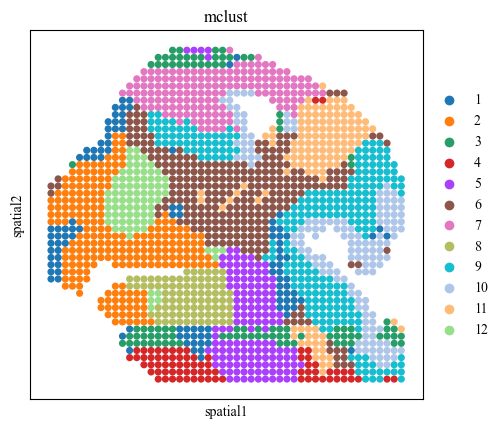

In [18]:
sc.pl.spatial(adata, img_key=None, color=['mclust'],spot_size=1,save='E13_ours.pdf')

In [16]:
#E13E13
from sklearn.metrics import normalized_mutual_info_score
NMI = normalized_mutual_info_score(adata.obs['mclust'], adata.obs[ 'Combined_Clusters_annotation'])
from sklearn.metrics import adjusted_mutual_info_score 
AMI= adjusted_mutual_info_score(adata.obs['mclust'], adata.obs['Combined_Clusters_annotation'])
from sklearn.metrics import v_measure_score
VMS = v_measure_score(adata.obs['mclust'], adata.obs['Combined_Clusters_annotation'])
from sklearn.metrics import homogeneity_score
HOM = homogeneity_score(adata.obs['mclust'], adata.obs['Combined_Clusters_annotation'])
print(AMI,NMI,VMS,HOM)

0.4258939829186826 0.4351965246594977 0.43519652465949765 0.3680989216318406


In [17]:
#E13
from sklearn.metrics import adjusted_rand_score as ari_score
#sc.tl.leiden(adata_new, resolution=0.2, key_added='ssgate_cluster',neighbors_key='SSGATE_neighbor')
print('ARI = %01.3f' % ari_score(adata.obs['mclust'], adata.obs['Combined_Clusters_annotation']))

ARI = 0.236


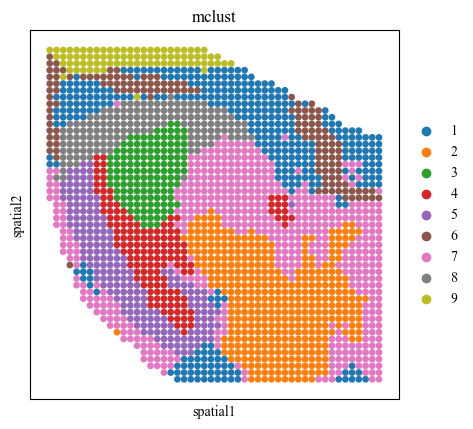

In [17]:
sc.pl.spatial(adata, img_key=None, color=['mclust'],spot_size=1,save='E18_ours_new.pdf')

In [18]:
adata3 = sc.read_h5ad('D:/biancheng/Data_SpatialGlue/Mouse_embryonic_brain/E18/E18_adata_with_interpolated_annotation.h5ad')
adata.obs['Interpolated_Domain']=adata3.obs['Interpolated_Domain']

In [7]:
#E18
from sklearn.metrics import normalized_mutual_info_score
NMI = normalized_mutual_info_score(adata.obs['mclust'], adata.obs[ 'Combined_Clusters_annotation'])
from sklearn.metrics import adjusted_mutual_info_score 
AMI= adjusted_mutual_info_score(adata.obs['mclust'], adata.obs['Combined_Clusters_annotation'])
from sklearn.metrics import v_measure_score
VMS = v_measure_score(adata.obs['mclust'], adata.obs['Combined_Clusters_annotation'])
from sklearn.metrics import homogeneity_score
HOM = homogeneity_score(adata.obs['mclust'], adata.obs['Combined_Clusters_annotation'])
print(AMI,NMI,VMS,HOM)

0.5450708684236512 0.5530549481610456 0.5530549481610455 0.5096466738465558


In [8]:
#E18
from sklearn.metrics import adjusted_rand_score as ari_score
#sc.tl.leiden(adata_new, resolution=0.2, key_added='ssgate_cluster',neighbors_key='SSGATE_neighbor')
print('ARI = %01.3f' % ari_score(adata.obs['mclust'], adata.obs['Combined_Clusters_annotation']))

ARI = 0.370


In [17]:
import st_datasets as stds
adata = stds.cl.mclust_R(adata, used_obsm='embeddingcom', num_cluster=11)


fitting ...


  |======================================================================| 100%


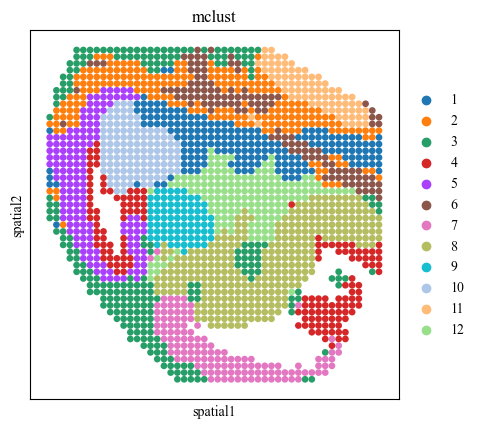

In [34]:
sc.pl.spatial(adata, img_key=None, color=['mclust'],spot_size=1,save='E15_ours_new.pdf')

In [35]:
adata3 = sc.read_h5ad('D:/biancheng/Data_SpatialGlue/Mouse_embryonic_brain/E15/E15_adata_with_interpolated_annotation.h5ad')
adata.obs['Interpolated_Domain']=adata3.obs['Interpolated_Domain']

In [25]:
#E15
from sklearn.metrics import normalized_mutual_info_score
NMI = normalized_mutual_info_score(adata.obs['mclust'], adata.obs[ 'Combined_Clusters_annotation'])
from sklearn.metrics import adjusted_mutual_info_score 
AMI= adjusted_mutual_info_score(adata.obs['mclust'], adata.obs['Combined_Clusters_annotation'])
from sklearn.metrics import v_measure_score
VMS = v_measure_score(adata.obs['mclust'], adata.obs['Combined_Clusters_annotation'])
from sklearn.metrics import homogeneity_score
HOM = homogeneity_score(adata.obs['mclust'], adata.obs['Combined_Clusters_annotation'])
print(AMI,NMI,VMS,HOM)

0.5493728371924014 0.5556915959311388 0.5556915959311387 0.5149299507048


In [26]:
#E15
from sklearn.metrics import adjusted_rand_score as ari_score
#sc.tl.leiden(adata_new, resolution=0.2, key_added='ssgate_cluster',neighbors_key='SSGATE_neighbor')
print('ARI = %01.3f' % ari_score(adata.obs['mclust'], adata.obs['Combined_Clusters_annotation']))

ARI = 0.371


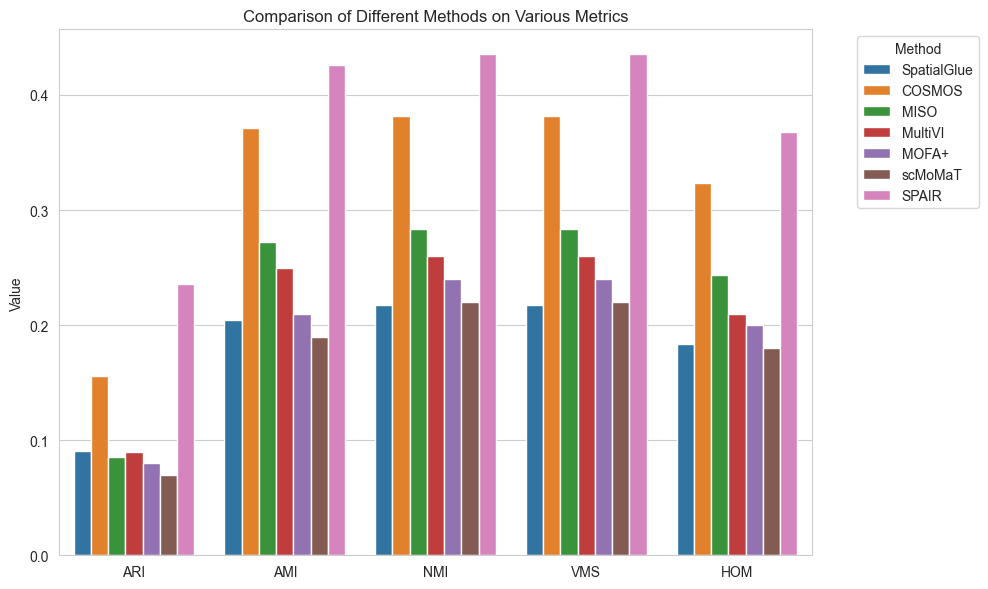

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
plt.rcParams["font.family"] = ["Times New Roman"]

methods = ["SpatialGlue", "COSMOS", "MISO" ,"MultiVI","MOFA+","scMoMaT","SPAIR",]
metrics = ["ARI", "AMI", "NMI", "VMS", "HOM"]
data = [
    [0.091,0.20465975375047823, 0.21749299342814482, 0.21749299342814485, 0.18333941042868826],
    [0.156,0.3712623200775087, 0.38147435922857115, 0.3814743592285711 ,0.3233350794389675],
    [0.085,0.27188077478687356 ,0.28383672125476467, 0.28383672125476467, 0.2438754412790141],
    [0.252,0.4201403192233572,0.42835807014715654,0.42835807014715654,0.4230987002651808],
    [0.300,0.45768873578020247,0.4654082756191979,0.46540827561919784,0.46294451770852885],
    [0.168,0.3296377689827675,0.33913898081900357,0.33913898081900357,0.334845884150055],
    [0.236,0.4258939829186826 ,0.4351965246594977 ,0.43519652465949765 ,0.3680989216318406],

]  


df = pd.DataFrame(data, columns=metrics, index=methods)
df = df.reset_index().melt(id_vars="index", var_name="Metric", value_name="Value")
df = df.rename(columns={"index": "Method"})


sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))


sns.barplot(x="Metric", y="Value", hue="Method", data=df)


plt.title("Comparison of Different Methods on Various Metrics")
plt.xlabel("")
plt.ylabel("Value")

plt.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig('E13_ARI.pdf', bbox_inches='tight')

plt.tight_layout()

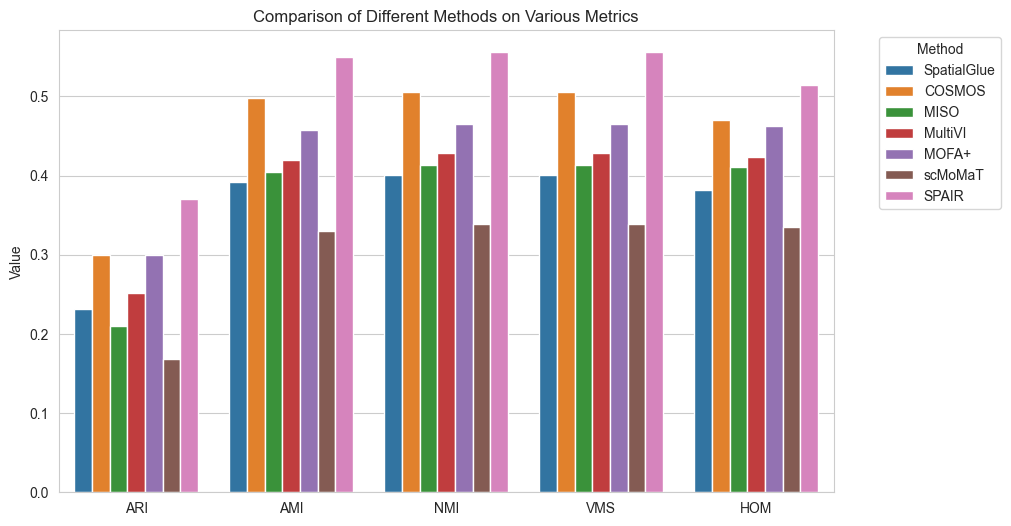

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
plt.rcParams["font.family"] = ["Times New Roman"]

methods = ["SpatialGlue", "COSMOS", "MISO" ,"MultiVI","MOFA+","scMoMaT","SPAIR",]
metrics = ["ARI", "AMI", "NMI", "VMS", "HOM"]
data = [
    [0.232,0.39145890497883135 ,0.40034138148088944, 0.40034138148088944 ,0.38116767828645476],
    [0.300,0.49809112482083123 ,0.5051656056234657, 0.5051656056234657 ,0.46977805787423393],
    [0.210,0.40405888535554507, 0.4132130735752592 ,0.41321307357525927 ,0.4113089568663683],
   [0.252,0.4201403192233572,0.42835807014715654,0.42835807014715654,0.4230987002651808],
    [0.300,0.45768873578020247,0.4654082756191979,0.46540827561919784,0.46294451770852885],
    [0.168,0.3296377689827675,0.33913898081900357,0.33913898081900357,0.334845884150055],
    [0.371,0.5493728371924014 ,0.5556915959311388 ,0.5556915959311387 ,0.5149299507048],
]  


df = pd.DataFrame(data, columns=metrics, index=methods)
df = df.reset_index().melt(id_vars="index", var_name="Metric", value_name="Value")
df = df.rename(columns={"index": "Method"})


sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))


sns.barplot(x="Metric", y="Value", hue="Method", data=df)


plt.title("Comparison of Different Methods on Various Metrics")
plt.xlabel("")
plt.ylabel("Value")


plt.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig('E15_ARI.pdf', bbox_inches='tight')

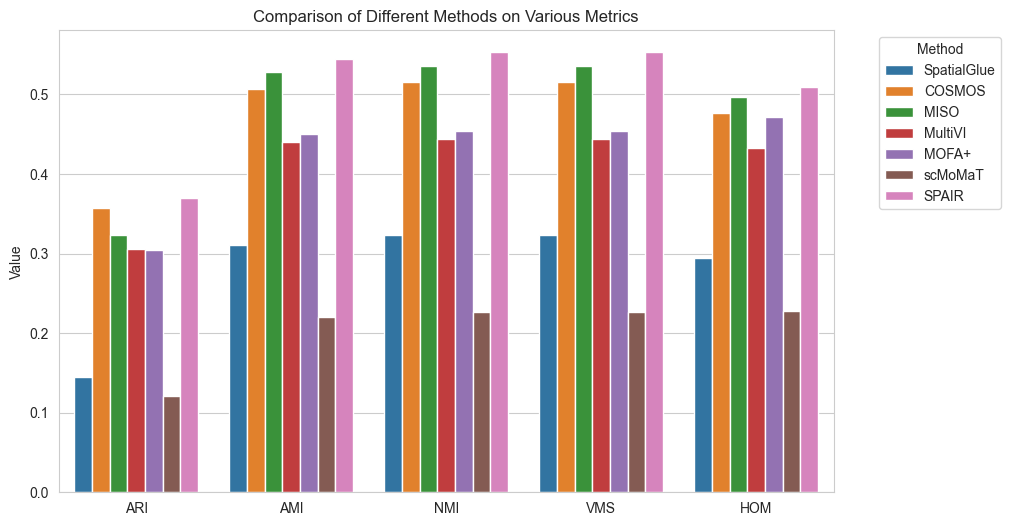

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
plt.rcParams["font.family"] = ["Times New Roman"]

methods = ["SpatialGlue", "COSMOS", "MISO" ,"MultiVI","MOFA+","scMoMaT","SPAIR",]
metrics = ["ARI", "AMI", "NMI", "VMS", "HOM"]
data = [
    [0.145,0.31090185721785535 ,0.32288898707155267 ,0.3228889870715527 ,0.2945876107720195],
    [0.357,0.507178577192239, 0.5158672854760482, 0.5158672854760481, 0.4772046185302461],
    [0.324,0.5277090317413042 ,0.5362089136298197 ,0.5362089136298197 ,0.4969037194795448],
    [0.306,0.4397836216206007,0.44394661036669975,0.44394661036669975,0.43322769397604377],
    [0.304,0.449844213689566,0.45422306377161825,0.45422306377161825,0.4720801359241135],
    [0.121,0.22081436130093002,0.22681911663641702,0.22681911663641702,0.22781967168054923],
    [0.370,0.5450708684236512, 0.5530549481610456 ,0.5530549481610455, 0.5096466738465558],
]  


df = pd.DataFrame(data, columns=metrics, index=methods)
df = df.reset_index().melt(id_vars="index", var_name="Metric", value_name="Value")
df = df.rename(columns={"index": "Method"})


sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))


sns.barplot(x="Metric", y="Value", hue="Method", data=df)


plt.title("Comparison of Different Methods on Various Metrics")
plt.xlabel("")
plt.ylabel("Value")


plt.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig('E18_ARI.pdf', bbox_inches='tight')